In [1]:
import sys
sys.path.append(".")

from utils import load_prices, compute_returns, build_network
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Ready")

Ready


Computing the rolling network density

In [2]:
prices = load_prices(start="2019-01-01", end="2024-12-31")
returns = compute_returns(prices)

window = 60
threshold = 0.5

dates = []
densities = []
avg_degrees = []

total_windows = len(returns) - window
for i in range(total_windows):
    window_returns = returns.iloc[i:i + window]
    G, _ = build_network(window_returns, threshold=threshold)

    n = G.number_of_nodes()
    e = G.number_of_edges()
    possible = n * (n-1) / 2
    density = e / possible
    avg_degree = np.mean([d for _, d in G.degree()])

    dates.append(returns.index[i + window])
    densities.append(density)
    avg_degrees.append(avg_degree)

rolling_df = pd.DataFrame({
    "density": densities,
    "avg_degree": avg_degrees
}, index=dates)

print(f"Computed {len(rolling_df)} rolling windows")
print(rolling_df.head())

[*********************100%***********************]  55 of 55 completed

8 Failed downloads:
['AMZN', 'ACN', 'MRK', 'TXN', 'IBM', 'CVX', 'ORCL', 'COST']: TypeError("'NoneType' object is not subscriptable")


Computed 2130 rolling windows
             density  avg_degree
2019-03-03  0.228492   10.510638
2019-03-04  0.228492   10.510638
2019-03-05  0.127660    5.872340
2019-03-06  0.061980    2.851064
2019-03-07  0.062905    2.893617


In [3]:
print(rolling_df.tail())

             density  avg_degree
2024-12-26  0.095282    4.382979
2024-12-27  0.095282    4.382979
2024-12-28  0.097132    4.468085
2024-12-29  0.103608    4.765957
2024-12-30  0.111008    5.106383


Plot the rolling density

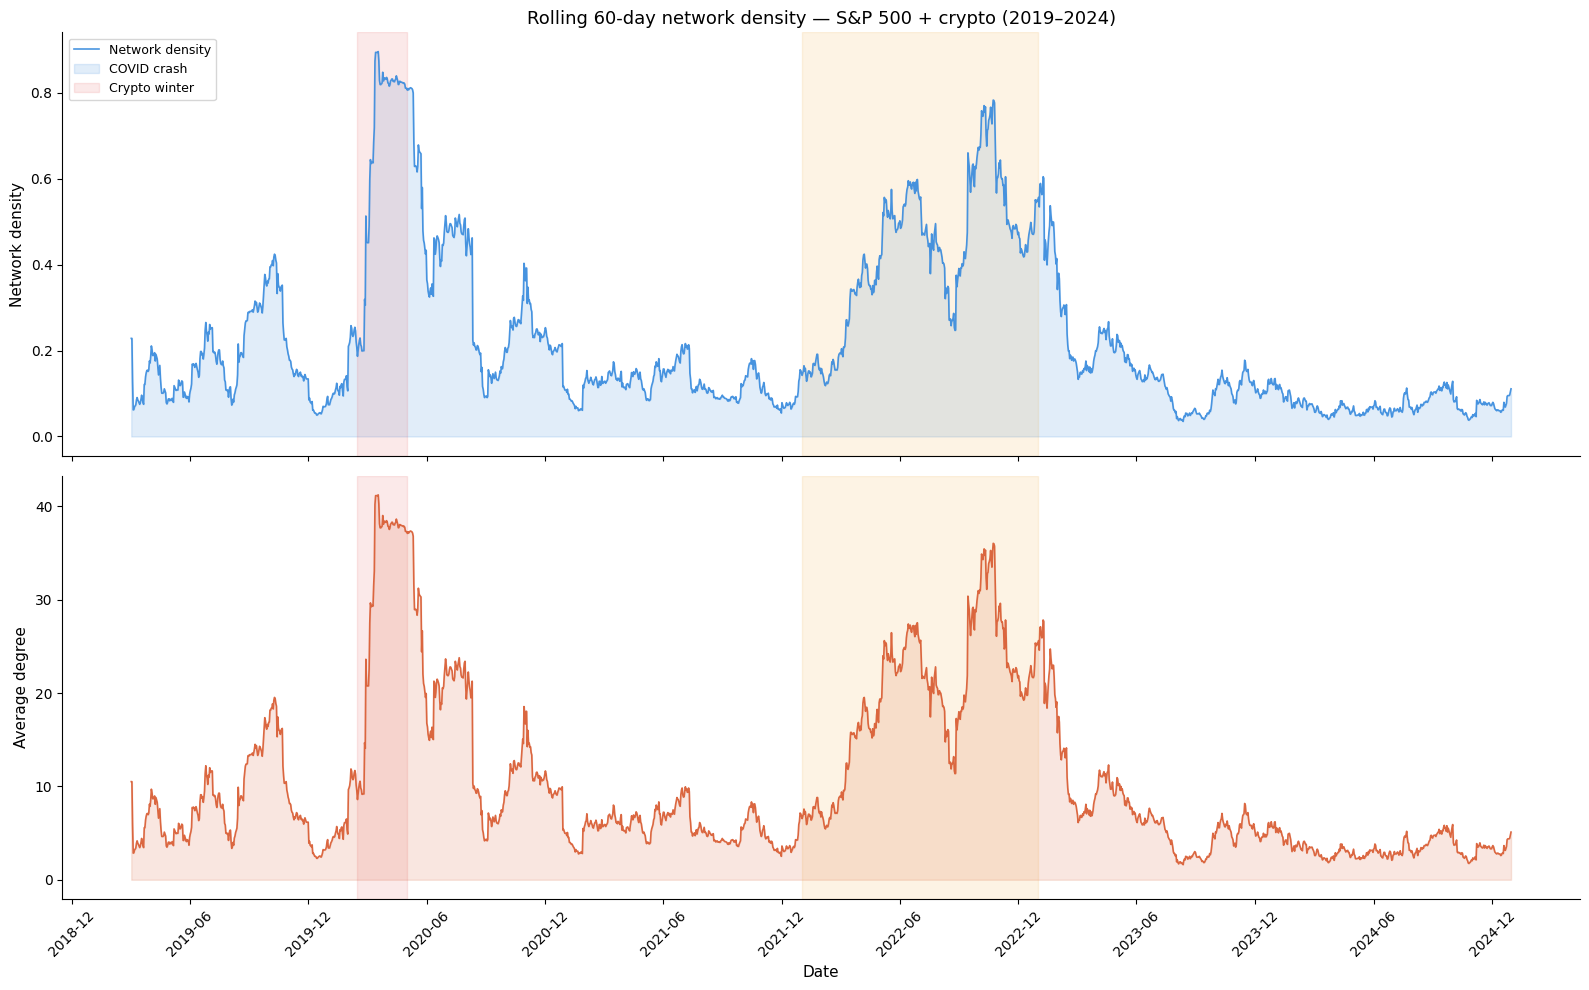

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Top panel: network density ---
ax1.plot(rolling_df.index, rolling_df["density"], 
         color="#378ADD", linewidth=1.2, alpha=0.9)
ax1.fill_between(rolling_df.index, rolling_df["density"], 
                 alpha=0.15, color="#378ADD")
ax1.set_ylabel("Network density", fontsize=11)
ax1.set_title("Rolling 60-day network density — S&P 500 + crypto (2019–2024)", 
              fontsize=13)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --- Bottom panel: average degree ---
ax2.plot(rolling_df.index, rolling_df["avg_degree"],
         color="#D85A30", linewidth=1.2, alpha=0.9)
ax2.fill_between(rolling_df.index, rolling_df["avg_degree"],
                 alpha=0.15, color="#D85A30")
ax2.set_ylabel("Average degree", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# --- Annotate crisis periods ---
crisis_periods = [
    ("2020-02-15", "2020-05-01", "#E24B4A", "COVID crash"),
    ("2022-01-01", "2022-12-31", "#EF9F27", "Crypto winter"),
]

for start, end, color, label in crisis_periods:
    for ax in [ax1, ax2]:
        ax.axvspan(start, end, alpha=0.12, color=color, label=label)

# Add legend for crisis periods
ax1.legend(["Network density", "COVID crash", "Crypto winter"], 
           loc="upper left", fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("rolling_density.png", dpi=150)
plt.show()